<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Notebook/Notebook_16_Input_Domain_Validation___OOD_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Title

# Notebook 16 — Input Domain Validation and Out-of-Distribution Detection

## Purpose

The final DenseNet121 classifier is a closed-set binary classifier.
Consequently, any input presented to the model will produce a Benign or
Malignant output even when the image does not belong to the lung CT
nodule domain used during model development.

This notebook introduces an input-domain validation stage using deep
feature embeddings extracted from the final validation-selected
DenseNet121 model.

The approach is designed to determine whether an uploaded image is
sufficiently similar to the preprocessed lung CT nodule images used to
develop the classifier.

Important:

- The method is not a medical-image modality classifier.
- It does not prove that an image is a CT scan.
- It acts as an out-of-distribution rejection mechanism.
- Images rejected by this stage must not receive a Benign/Malignant
  classification.

Methodology:

Training set
→ DenseNet121 feature embeddings
→ reference feature distribution

Validation set
→ k-nearest-neighbour feature distance
→ acceptance threshold calibration

Test set
→ final in-domain acceptance evaluation

External images
→ out-of-domain rejection evaluation

##2. Imports

In [49]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)


##3. Mount Drive

In [50]:
from google.colab import drive

MOUNT_POINT = "/content/drive"

if os.path.ismount(MOUNT_POINT):
    print("Google Drive already mounted.")
else:
    drive.mount(MOUNT_POINT)

Google Drive already mounted.


##4. Define project paths

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "Models"
)

DENSENET_ROOT = (
    MODEL_ROOT
    / "DenseNet121"
    / "Corrected_Run_01"
)

MODEL_PATH = (
    DENSENET_ROOT
    / "FineTune_Last30"
    / "best_model.keras"
)

OOD_ROOT = (
    MODEL_ROOT
    / "Domain_Validation"
)

OOD_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Model exists:", MODEL_PATH.exists())
print("OOD output:", OOD_ROOT)

Model exists: True
OOD output: /content/drive/MyDrive/Dissertation/Models/Domain_Validation


##5. DenseNet preprocessing class

In [4]:
@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class DenseNetPreprocessing(
    tf.keras.layers.Layer
):

    def call(self, inputs):

        return (
            tf.keras.applications
            .densenet
            .preprocess_input(inputs)
        )

    def get_config(self):

        return super().get_config()

##6. Load final DenseNet121

In [5]:
densenet_model = tf.keras.models.load_model(
    MODEL_PATH,

    custom_objects={
        "DenseNetPreprocessing":
            DenseNetPreprocessing,

        "LungNoduleClassification>DenseNetPreprocessing":
            DenseNetPreprocessing
    },

    compile=False
)

print("Loaded:", densenet_model.name)
print("Input:", densenet_model.input_shape)
print("Output:", densenet_model.output_shape)

Loaded: DenseNet121_LungNoduleClassifier
Input: (None, 128, 128, 3)
Output: (None, 1)


##7. Load the patient-level splits

In [6]:

PROCESSED_PATH = (
    PROJECT_ROOT /
    "Dataset" /
    "Processed"
)


TRAIN_CSV = PROCESSED_PATH / "train.csv"
VALIDATION_CSV = PROCESSED_PATH / "validation.csv"
TEST_CSV = PROCESSED_PATH / "test.csv"

In [7]:
train_df = pd.read_csv(TRAIN_CSV)

validation_df = pd.read_csv(VALIDATION_CSV)

test_df = pd.read_csv(TEST_CSV)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(1149, 5)
(237, 5)
(256, 5)


### Resolve Colab image paths

In [8]:
CNN_DATASET_ROOT = (
    PROCESSED_PATH
    / "CNN_Dataset"
)

def resolve_image_path(row):

    label_name = (
        "Malignant"
        if int(row["CancerLabel"]) == 1
        else "Benign"
    )

    original_path = Path(
        str(row["ImagePath"])
    )

    filename = (
        original_path.name
    )

    resolved_path = (
        CNN_DATASET_ROOT
        / label_name
        / filename
    )

    return str(
        resolved_path
    )

In [9]:
# ============================================================
# Resolve image paths for ALL patient-level splits
# ============================================================

train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()


for df in [
    train_df,
    validation_df,
    test_df
]:
    df["ResolvedImagePath"] = df.apply(
        resolve_image_path,
        axis=1
    )


print(
    "CNN dataset root:",
    CNN_DATASET_ROOT
)

print(
    "\nResolved image paths:"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "Test:",
    len(test_df)
)

CNN dataset root: /content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset

Resolved image paths:
Train: 1149
Validation: 237
Test: 256


In [ ]:
# ============================================================
# Verify patient-level splits
# ============================================================

print("=" * 60)
print("PATIENT-LEVEL SPLIT SUMMARY")
print("=" * 60)

for split_name, df in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:

    print(
        f"{split_name:<12}"
        f"Images: {len(df):<5}"
        f"Patients: {df['PatientID'].nunique()}"
    )


train_patients = set(
    train_df["PatientID"]
)

validation_patients = set(
    validation_df["PatientID"]
)

test_patients = set(
    test_df["PatientID"]
)


print("\nPatient overlap:")

print(
    "Train ↔ Validation:",
    len(
        train_patients
        & validation_patients
    )
)

print(
    "Train ↔ Test:",
    len(
        train_patients
        & test_patients
    )
)

print(
    "Validation ↔ Test:",
    len(
        validation_patients
        & test_patients
    )
)

PATIENT-LEVEL SPLIT SUMMARY
Train       Images: 1149 Patients: 467
Validation  Images: 237  Patients: 100
Test        Images: 256  Patients: 101

Patient overlap:
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


##8. Image Loader

In [10]:
IMAGE_SIZE = (
    128,
    128
)


def load_image(
    image_path
):

    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

##9. Build feature datasets

In [11]:
BATCH_SIZE = 16

AUTOTUNE = (
    tf.data.AUTOTUNE
)


def build_feature_dataset(
    dataframe
):

    paths = (
        dataframe[
            "ResolvedImagePath"
        ]
        .values
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(paths)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [12]:
# Create #

train_feature_ds = (
    build_feature_dataset(
        train_df
    )
)

validation_feature_ds = (
    build_feature_dataset(
        validation_df
    )
)

test_feature_ds = (
    build_feature_dataset(
        test_df
    )
)

print(
    "Feature datasets created successfully."
)

Feature datasets created successfully.


##10. Locate DenseNet121 feature layer

In [13]:
gap_layers = [
    layer
    for layer
    in densenet_model.layers

    if isinstance(
        layer,
        tf.keras.layers.GlobalAveragePooling2D
    )
]

print(
    "GlobalAveragePooling2D layers:",
    [
        layer.name
        for layer
        in gap_layers
    ]
)

GlobalAveragePooling2D layers: ['global_average_pooling']


In [14]:
if len(gap_layers) == 0:

    raise RuntimeError(
        "No GlobalAveragePooling2D "
        "layer found."
    )

FEATURE_LAYER = (
    gap_layers[-1]
)

FEATURE_LAYER_NAME = (
    FEATURE_LAYER.name
)

print(
    "Selected feature layer:",
    FEATURE_LAYER_NAME
)

print(
    "Feature shape:",
    FEATURE_LAYER.output.shape
)

Selected feature layer: global_average_pooling
Feature shape: (None, 1024)


##11. Build feature extractor

In [15]:
feature_model = tf.keras.Model(
    inputs=densenet_model.input,
    outputs=FEATURE_LAYER.output,
    name="DenseNet121_Domain_Feature_Extractor"
)

print(
    feature_model.output_shape
)

(None, 1024)


##12. Extract train/validation/test embeddings

In [16]:
train_embeddings = (
    feature_model.predict(
        train_feature_ds,
        verbose=1
    )
)

validation_embeddings = (
    feature_model.predict(
        validation_feature_ds,
        verbose=1
    )
)

test_embeddings = (
    feature_model.predict(
        test_feature_ds,
        verbose=1
    )
)

print(
    "Train:",
    train_embeddings.shape
)

print(
    "Validation:",
    validation_embeddings.shape
)

print(
    "Test:",
    test_embeddings.shape
)

72/72 ━━━━━━━━━━━━━━━━━━━━ 449s 6s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 90s 6s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 97s 6s/step
Train: (1149, 1024)
Validation: (237, 1024)
Test: (256, 1024)


##13. L2-normalise embeddings

In [17]:
def normalize_embeddings(
    embeddings
):

    norms = np.linalg.norm(
        embeddings,
        axis=1,
        keepdims=True
    )

    return (
        embeddings
        /
        np.maximum(
            norms,
            1e-8
        )
    )

In [18]:
train_embeddings_norm = (
    normalize_embeddings(
        train_embeddings
    )
)

validation_embeddings_norm = (
    normalize_embeddings(
        validation_embeddings
    )
)

test_embeddings_norm = (
    normalize_embeddings(
        test_embeddings
    )
)

In [19]:
print(
    np.linalg.norm(
        train_embeddings_norm[0]
    )
)

1.0


##14. Define k-NN domain distance

In [20]:
K_NEIGHBORS = 5


def calculate_domain_distance(
    query_embeddings,
    reference_embeddings,
    k=5
):
    """
    Cosine k-NN domain distance.

    Smaller = more similar to training domain.
    Larger  = less similar to training domain.
    """

    similarities = (
        query_embeddings
        @ reference_embeddings.T
    )

    k = min(
        k,
        reference_embeddings.shape[0]
    )

    top_k_similarities = np.partition(
        similarities,
        -k,
        axis=1
    )[:, -k:]

    mean_similarity = (
        np.mean(
            top_k_similarities,
            axis=1
        )
    )

    distance = (
        1.0
        - mean_similarity
    )

    return distance

##15. Calculate validation distances

TRAIN = reference

VALIDATION = threshold calibration

In [21]:
validation_distances = (
    calculate_domain_distance(
        validation_embeddings_norm,
        train_embeddings_norm,
        k=K_NEIGHBORS
    )
)

print(
    "Validation distance mean:",
    validation_distances.mean()
)

print(
    "Validation distance median:",
    np.median(
        validation_distances
    )
)

print(
    "Validation distance maximum:",
    validation_distances.max()
)

Validation distance mean: 0.14623085
Validation distance median: 0.12685472
Validation distance maximum: 0.35635585


##16. Select acceptance threshold

In [23]:
THRESHOLD_PERCENTILE = 95

DOMAIN_THRESHOLD = float(
    np.percentile(
        validation_distances,
        THRESHOLD_PERCENTILE
    )
)

print(
    "Domain threshold:",
    DOMAIN_THRESHOLD
)

Domain threshold: 0.2859232425689697


##17. Validation acceptance rate

In [24]:
validation_accepted = (
    validation_distances
    <= DOMAIN_THRESHOLD
)

validation_acceptance_rate = (
    validation_accepted.mean()
)

print(
    "Validation acceptance rate:",
    validation_acceptance_rate
)

Validation acceptance rate: 0.9493670886075949


##18. Evaluate untouched in-domain test set

In [25]:
test_distances = (
    calculate_domain_distance(
        test_embeddings_norm,
        train_embeddings_norm,
        k=K_NEIGHBORS
    )
)

test_accepted = (
    test_distances
    <= DOMAIN_THRESHOLD
)

test_acceptance_rate = (
    test_accepted.mean()
)

print(
    "In-domain test acceptance:",
    test_acceptance_rate
)

print(
    "In-domain test rejected:",
    1 - test_acceptance_rate
)

In-domain test acceptance: 0.94921875
In-domain test rejected: 0.05078125


### 18.1 Class-Specific In-Domain Acceptance

The overall test acceptance rate should also be examined separately for
Benign and Malignant nodules.

This analysis checks whether the domain-validation gate disproportionately
rejects one of the two classifier classes.

In [26]:
# ============================================================
# Class-Specific In-Domain Acceptance
# ============================================================

test_domain_results = (
    test_df.copy()
)

test_domain_results[
    "DomainDistance"
] = test_distances

test_domain_results[
    "DomainAccepted"
] = test_accepted

In [27]:
class_acceptance_summary = (
    test_domain_results
    .groupby(
        "CancerLabel"
    )
    .agg(
        Samples=(
            "DomainAccepted",
            "size"
        ),

        Accepted=(
            "DomainAccepted",
            "sum"
        ),

        Rejected=(
            "DomainAccepted",
            lambda x: (~x).sum()
        ),

        AcceptanceRate=(
            "DomainAccepted",
            "mean"
        ),

        MeanDistance=(
            "DomainDistance",
            "mean"
        ),

        MedianDistance=(
            "DomainDistance",
            "median"
        )
    )
    .reset_index()
)


class_acceptance_summary[
    "Class"
] = (
    class_acceptance_summary[
        "CancerLabel"
    ]
    .map(
        {
            0: "Benign",
            1: "Malignant"
        }
    )
)


class_acceptance_summary[
    "RejectionRate"
] = (
    1
    - class_acceptance_summary[
        "AcceptanceRate"
    ]
)


display(
    class_acceptance_summary[
        [
            "Class",
            "Samples",
            "Accepted",
            "Rejected",
            "AcceptanceRate",
            "RejectionRate",
            "MeanDistance",
            "MedianDistance"
        ]
    ]
)

,Class,Samples,Accepted,Rejected,AcceptanceRate,RejectionRate,MeanDistance,MedianDistance
0,Benign,221,217,4,0.981900,0.018100,0.141344,0.130112
1,Malignant,35,26,9,0.742857,0.257143,0.237690,0.246567


### 18.2 Inspection of Rejected Legitimate CT Nodule Inputs

Because the validation-derived threshold intentionally rejects a small
proportion of in-domain inputs, the rejected test samples are examined
to understand which legitimate lung CT nodule images are treated as
feature-space outliers.

These samples remain part of the untouched test set and are not used
to modify the domain threshold.

In [28]:
# ============================================================
# Identify Rejected In-Domain Test Samples
# ============================================================

rejected_test_cases = (
    test_domain_results[
        ~test_domain_results[
            "DomainAccepted"
        ]
    ]
    .sort_values(
        "DomainDistance",
        ascending=False
    )
    .copy()
)


print(
    "Rejected legitimate test images:",
    len(
        rejected_test_cases
    )
)

print(
    "Total test images:",
    len(
        test_domain_results
    )
)

print(
    "Rejection rate:",
    len(
        rejected_test_cases
    )
    /
    len(
        test_domain_results
    )
)


display(
    rejected_test_cases[
        [
            "PatientID",
            "NoduleID",
            "CancerLabel",
            "LabelName",
            "DomainDistance",
            "ResolvedImagePath"
        ]
    ]
)

Rejected legitimate test images: 13
Total test images: 256
Rejection rate: 0.05078125


,PatientID,NoduleID,CancerLabel,LabelName,DomainDistance,ResolvedImagePath
208,LIDC-IDRI-0750,3,0,Benign,0.380508,/content/drive/MyDrive/Dissertation/Dataset/Pr...
227,LIDC-IDRI-0910,1,0,Benign,0.366054,/content/drive/MyDrive/Dissertation/Dataset/Pr...
220,LIDC-IDRI-0986,1,0,Benign,0.351549,/content/drive/MyDrive/Dissertation/Dataset/Pr...
196,LIDC-IDRI-0575,1,1,Malignant,0.345726,/content/drive/MyDrive/Dissertation/Dataset/Pr...
166,LIDC-IDRI-0466,2,1,Malignant,0.338315,/content/drive/MyDrive/Dissertation/Dataset/Pr...
135,LIDC-IDRI-0385,2,1,Malignant,0.335333,/content/drive/MyDrive/Dissertation/Dataset/Pr...
70,LIDC-IDRI-0229,2,1,Malignant,0.331704,/content/drive/MyDrive/Dissertation/Dataset/Pr...
58,LIDC-IDRI-0195,6,0,Benign,0.329208,/content/drive/MyDrive/Dissertation/Dataset/Pr...
99,LIDC-IDRI-0337,1,1,Malignant,0.323155,/content/drive/MyDrive/Dissertation/Dataset/Pr...
24,LIDC-IDRI-0116,2,1,Malignant,0.322262,/content/drive/MyDrive/Dissertation/Dataset/Pr...


####Visualize them

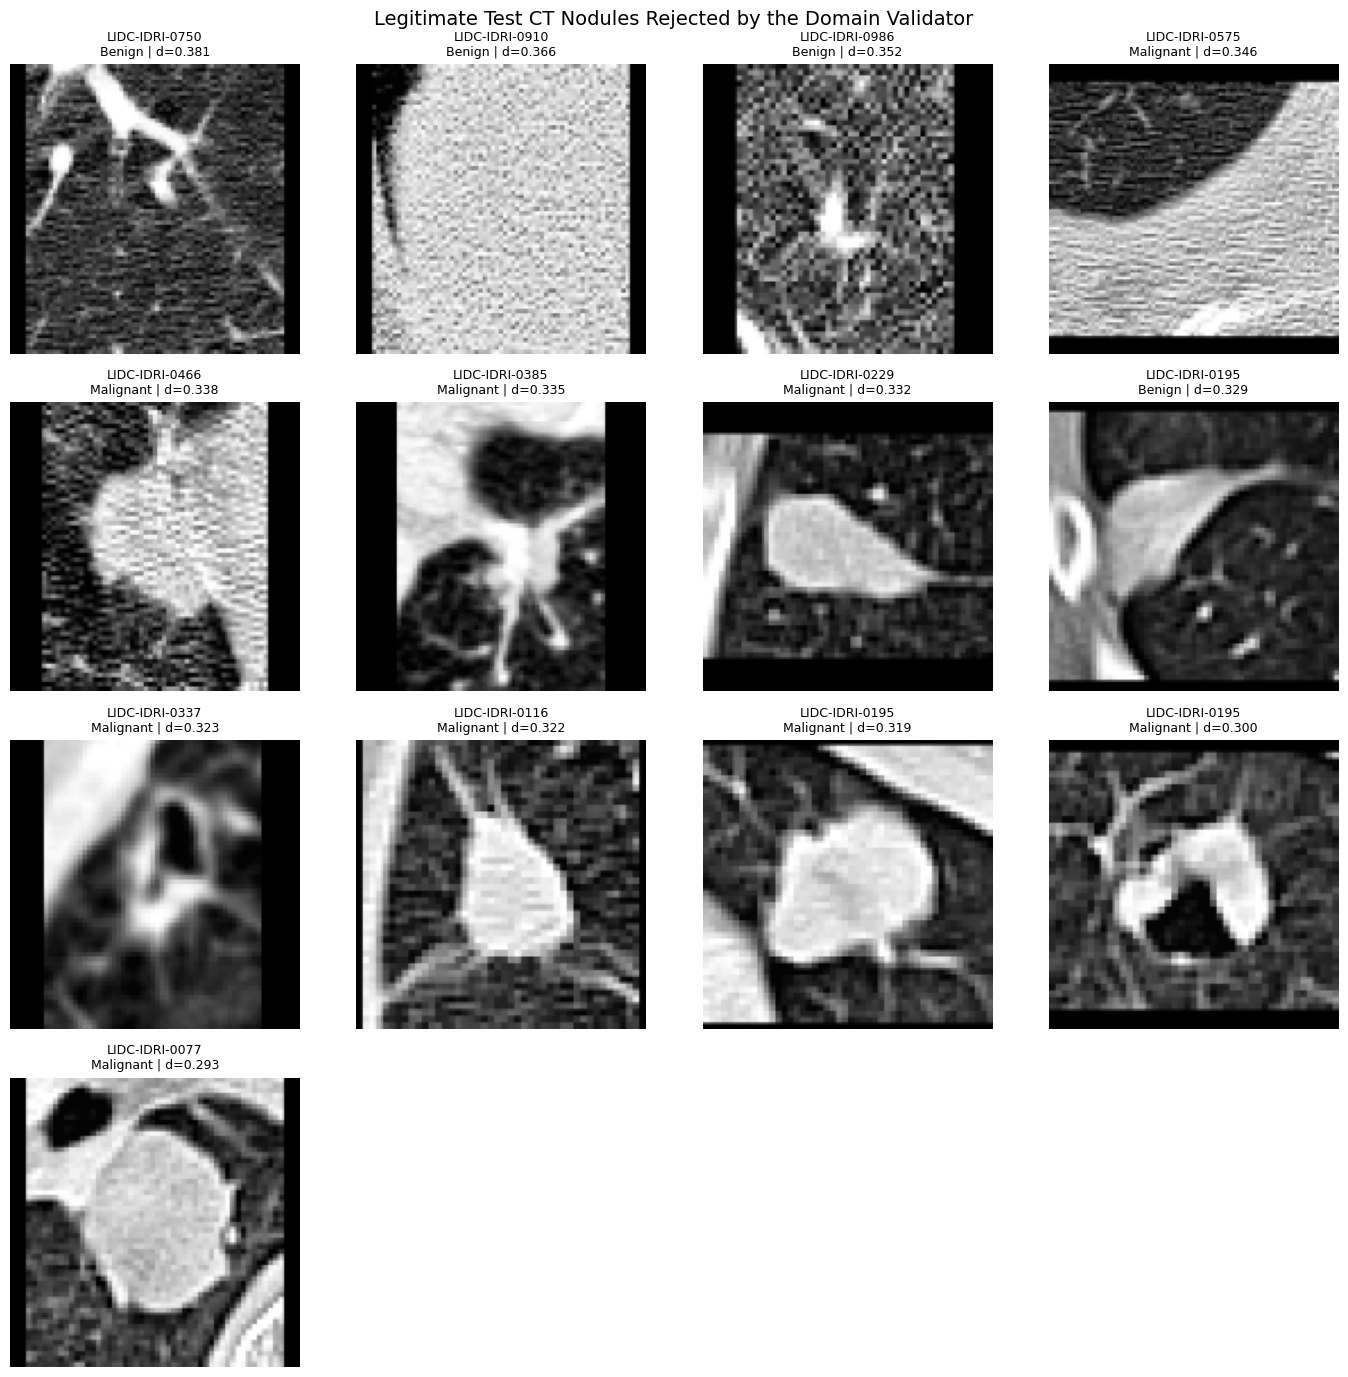

In [29]:
# ============================================================
# Visualize Rejected Legitimate CT Nodules
# ============================================================

n_rejected = len(
    rejected_test_cases
)

columns = 4

rows = int(
    np.ceil(
        n_rejected
        / columns
    )
)


plt.figure(
    figsize=(
        14,
        3.5 * rows
    )
)


for plot_index, (
    _,
    row
) in enumerate(
    rejected_test_cases
    .iterrows(),
    start=1
):

    image = (
        tf.io.read_file(
            row[
                "ResolvedImagePath"
            ]
        )
    )

    image = tf.image.decode_png(
        image,
        channels=3
    )

    plt.subplot(
        rows,
        columns,
        plot_index
    )

    plt.imshow(
        image.numpy()
        .astype(
            np.uint8
        )
    )

    class_name = (
        "Malignant"
        if int(
            row["CancerLabel"]
        ) == 1
        else "Benign"
    )

    plt.title(
        f"{row['PatientID']}\n"
        f"{class_name} | "
        f"d={row['DomainDistance']:.3f}",
        fontsize=9
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Legitimate Test CT Nodules Rejected by the Domain Validator",
    fontsize=14
)

plt.tight_layout()

plt.show()

## 19. Natural-Image Out-of-Distribution Evaluation

For a reproducible first OOD experiment, CIFAR-10 is convenient.

In [32]:
(
    _,
    _
), (
    cifar_test_images,
    _
) = (
    tf.keras.datasets
    .cifar10
    .load_data()
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2771s 16us/step


####Take 500

In [33]:
OOD_SAMPLE_COUNT = 500

cifar_ood_images = (
    cifar_test_images[
        :OOD_SAMPLE_COUNT
    ]
)

print(
    cifar_ood_images.shape
)

(500, 32, 32, 3)


####Build dataset:

In [34]:
def preprocess_ood_image(
    image
):

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

### Natural-Image OOD Evaluation

CIFAR-10 is used here as an initial clearly out-of-domain dataset.

It is not used to train the domain validator or select the acceptance
threshold. The acceptance threshold has already been determined using
the in-domain validation set.

Therefore, CIFAR-10 is used only to evaluate whether the feature-space
domain validator can reject obviously unrelated natural images.

A subsequent experiment should evaluate more challenging medical
out-of-domain inputs such as chest X-rays and MRI images.

In [35]:
cifar_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        cifar_ood_images
    )
    .map(
        preprocess_ood_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        AUTOTUNE
    )
)

####Extract:

In [36]:
cifar_embeddings = (
    feature_model.predict(
        cifar_ds,
        verbose=1
    )
)

cifar_embeddings_norm = (
    normalize_embeddings(
        cifar_embeddings
    )
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 473ms/step


In [37]:
# ============================================================
# Verify embedding dimensions
# ============================================================

assert (
    train_embeddings.shape[0]
    == len(train_df)
)

assert (
    validation_embeddings.shape[0]
    == len(validation_df)
)

assert (
    test_embeddings.shape[0]
    == len(test_df)
)

assert (
    train_embeddings.shape[1]
    == validation_embeddings.shape[1]
    == test_embeddings.shape[1]
)

print(
    "Embedding validation passed."
)

print(
    "Feature dimension:",
    train_embeddings.shape[1]
)

Embedding validation passed.
Feature dimension: 1024


####Calculate distances

In [38]:
cifar_distances = (
    calculate_domain_distance(
        cifar_embeddings_norm,
        train_embeddings_norm,
        k=K_NEIGHBORS
    )
)

cifar_rejected = (
    cifar_distances
    > DOMAIN_THRESHOLD
)

cifar_rejection_rate = (
    cifar_rejected.mean()
)

print(
    "Natural-image rejection rate:",
    cifar_rejection_rate
)

Natural-image rejection rate: 1.0


### 19.2 Threshold-Independent CT-vs-CIFAR OOD Discrimination

In addition to evaluating rejection at the predefined validation-derived
threshold, ROC-AUC is calculated as a threshold-independent measure of
feature-space separation between in-domain lung CT nodules and clearly
out-of-domain natural images.

Higher domain distance represents greater evidence of an out-of-domain
input.

The OOD labels and scores in this section are used only for evaluation
and do not alter the previously selected domain threshold.

In [39]:
# ============================================================
# CT vs CIFAR OOD ROC-AUC
# ============================================================

# 0 = In-domain CT
# 1 = Out-of-domain CIFAR

ood_true = np.concatenate(
    [
        np.zeros(
            len(
                test_distances
            ),
            dtype=np.int32
        ),

        np.ones(
            len(
                cifar_distances
            ),
            dtype=np.int32
        )
    ]
)


ood_scores = np.concatenate(
    [
        test_distances,
        cifar_distances
    ]
)


ct_cifar_ood_auc = (
    roc_auc_score(
        ood_true,
        ood_scores
    )
)


print(
    "CT vs CIFAR OOD ROC-AUC:",
    ct_cifar_ood_auc
)

CT vs CIFAR OOD ROC-AUC: 1.0


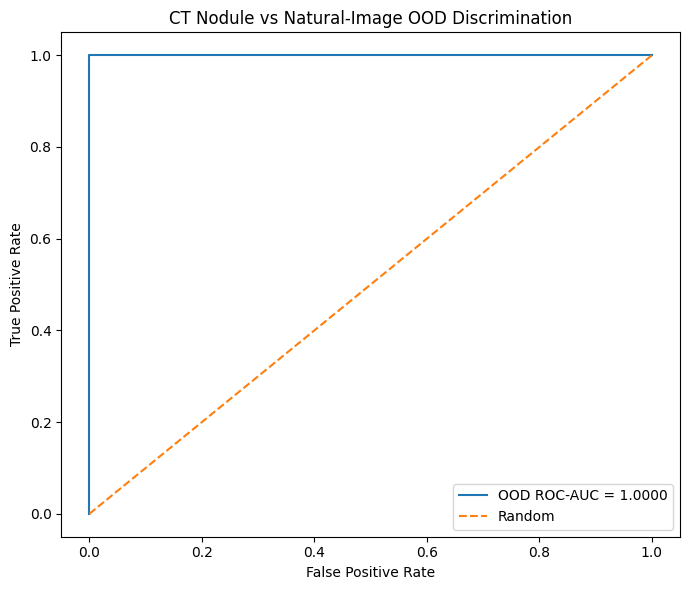

In [40]:
fpr_ood, \
tpr_ood, \
_ = roc_curve(
    ood_true,
    ood_scores
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr_ood,
    tpr_ood,
    label=(
        f"OOD ROC-AUC = "
        f"{ct_cifar_ood_auc:.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "CT Nodule vs Natural-Image OOD Discrimination"
)

plt.legend()

plt.tight_layout()

plt.show()

##20. Compare distributions

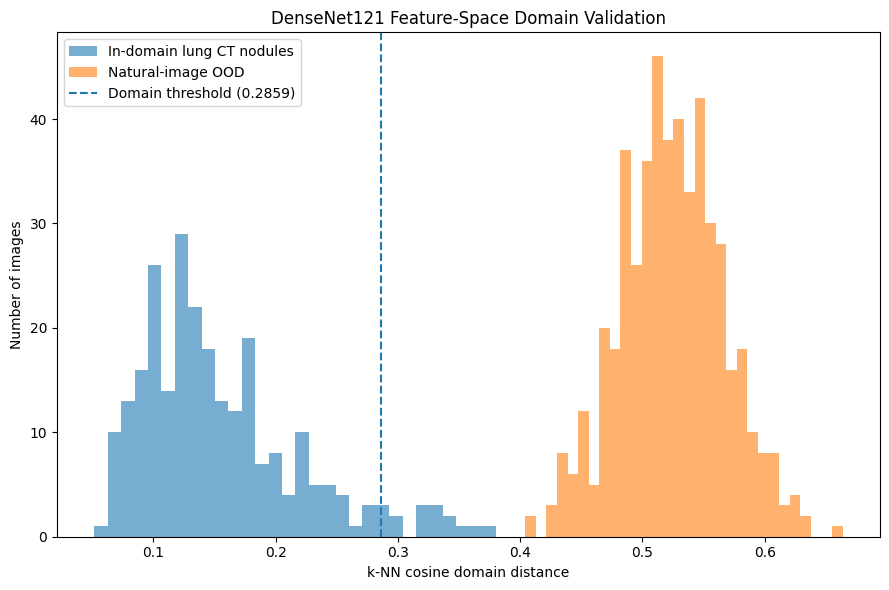

In [41]:
plt.figure(
    figsize=(9, 6)
)

plt.hist(
    test_distances,
    bins=30,
    alpha=0.6,
    label="In-domain lung CT nodules"
)

plt.hist(
    cifar_distances,
    bins=30,
    alpha=0.6,
    label="Natural-image OOD"
)

plt.axvline(
    DOMAIN_THRESHOLD,
    linestyle="--",
    label=(
        f"Domain threshold "
        f"({DOMAIN_THRESHOLD:.4f})"
    )
)

plt.xlabel(
    "k-NN cosine domain distance"
)

plt.ylabel(
    "Number of images"
)

plt.title(
    "DenseNet121 Feature-Space Domain Validation"
)

plt.legend()

plt.tight_layout()

plt.show()

## 21. Medical Out-of-Distribution Evaluation

Natural photographs represent an obvious out-of-domain condition.
A more challenging robustness experiment evaluates whether the
feature-space validator can reject medical images that are visually
closer to the trained CT nodule domain but remain unsupported by the
classifier.

The following external image categories are evaluated:

- Chest X-ray
- MRI
- Ultrasound

These datasets are used strictly for final OOD evaluation. They are not
used to select or modify the domain-validation threshold.

###21.1 Medical OOD folder paths

In [51]:
# ============================================================
# Medical OOD Evaluation Paths
# ============================================================

MEDICAL_OOD_ROOT = (
    PROJECT_ROOT
    / "OOD_Evaluation"
)

XRAY_DIR = (
    MEDICAL_OOD_ROOT
    / "Chest_Xray"
)

MRI_DIR = (
    MEDICAL_OOD_ROOT
    / "MRI"
)

ULTRASOUND_DIR = (
    MEDICAL_OOD_ROOT
    / "Ultrasound"
)

print(XRAY_DIR)


print(
    "Chest X-ray folder:",
    XRAY_DIR.exists()
)

print(
    "MRI folder:",
    MRI_DIR.exists()
)

print(
    "Ultrasound folder:",
    ULTRASOUND_DIR.exists()
)

/content/drive/MyDrive/Dissertation/OOD_Evaluation/Chest_Xray
Chest X-ray folder: True
MRI folder: True
Ultrasound folder: True


### 21.2 External Medical Image Loading

In [52]:
# ============================================================
# Collect External Medical Images
# ============================================================

SUPPORTED_EXTERNAL_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg"
}


def collect_image_paths(
    directory
):

    directory = Path(
        directory
    )

    if not directory.exists():

        return []

    image_paths = sorted(
        [
            path

            for path
            in directory.rglob("*")

            if (
                path.is_file()

                and

                path.suffix.lower()
                in SUPPORTED_EXTERNAL_EXTENSIONS
            )
        ]
    )

    return image_paths

In [54]:
def load_external_image(
    image_path
):

    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [
            None,
            None,
            3
        ]
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

### 21.3 Generic Medical OOD Evaluation Function

In [55]:
def evaluate_external_ood_folder(
    folder_path,
    dataset_name
):

    image_paths = (
        collect_image_paths(
            folder_path
        )
    )

    print(
        "=" * 60
    )

    print(
        dataset_name
    )

    print(
        "Images:",
        len(
            image_paths
        )
    )


    if len(
        image_paths
    ) == 0:

        print(
            "No images found."
        )

        return None


    path_strings = [
        str(path)
        for path
        in image_paths
    ]


    external_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            path_strings
        )
        .map(
            load_external_image,
            num_parallel_calls=AUTOTUNE
        )
        .batch(
            BATCH_SIZE
        )
        .prefetch(
            AUTOTUNE
        )
    )


    embeddings = (
        feature_model.predict(
            external_ds,
            verbose=1
        )
    )


    embeddings_norm = (
        normalize_embeddings(
            embeddings
        )
    )


    distances = (
        calculate_domain_distance(
            embeddings_norm,
            train_embeddings_norm,
            k=K_NEIGHBORS
        )
    )


    accepted = (
        distances
        <= DOMAIN_THRESHOLD
    )


    rejected = (
        ~accepted
    )


    result = {

        "Dataset":
            dataset_name,

        "Samples":
            int(
                len(
                    distances
                )
            ),

        "MeanDistance":
            float(
                np.mean(
                    distances
                )
            ),

        "MedianDistance":
            float(
                np.median(
                    distances
                )
            ),

        "MinimumDistance":
            float(
                np.min(
                    distances
                )
            ),

        "MaximumDistance":
            float(
                np.max(
                    distances
                )
            ),

        "Accepted":
            int(
                accepted.sum()
            ),

        "Rejected":
            int(
                rejected.sum()
            ),

        "AcceptanceRate":
            float(
                accepted.mean()
            ),

        "RejectionRate":
            float(
                rejected.mean()
            )
    }


    print(
        "Acceptance rate:",
        result[
            "AcceptanceRate"
        ]
    )

    print(
        "Rejection rate:",
        result[
            "RejectionRate"
        ]
    )


    return {
        "summary":
            result,

        "distances":
            distances,

        "paths":
            image_paths,

        "accepted":
            accepted,

        "rejected":
            rejected
    }

### 21.4 Evaluate Medical OOD Categories

In [56]:
xray_evaluation = (
    evaluate_external_ood_folder(
        XRAY_DIR,
        "Chest_Xray"
    )
)


mri_evaluation = (
    evaluate_external_ood_folder(
        MRI_DIR,
        "MRI"
    )
)


ultrasound_evaluation = (
    evaluate_external_ood_folder(
        ULTRASOUND_DIR,
        "Ultrasound"
    )
)

Chest_Xray
Images: 51
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step
Acceptance rate: 0.9803921568627451
Rejection rate: 0.0196078431372549
MRI
Images: 80
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step
Acceptance rate: 0.0
Rejection rate: 1.0
Ultrasound
Images: 55
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step
Acceptance rate: 0.0
Rejection rate: 1.0


### 21.5 Medical OOD Summary

In [57]:
medical_ood_results = [
    result["summary"]

    for result in [
        xray_evaluation,
        mri_evaluation,
        ultrasound_evaluation
    ]

    if result is not None
]


medical_ood_summary = (
    pd.DataFrame(
        medical_ood_results
    )
)


display(
    medical_ood_summary
)

,Dataset,Samples,MeanDistance,MedianDistance,MinimumDistance,MaximumDistance,Accepted,Rejected,AcceptanceRate,RejectionRate
0,Chest_Xray,51,0.150199,0.129414,0.057763,0.292032,50,1,0.980392,0.019608
1,MRI,80,0.463221,0.458706,0.397988,0.551626,0,80,0.000000,1.000000
2,Ultrasound,55,0.482604,0.485217,0.433678,0.548432,0,55,0.000000,1.000000


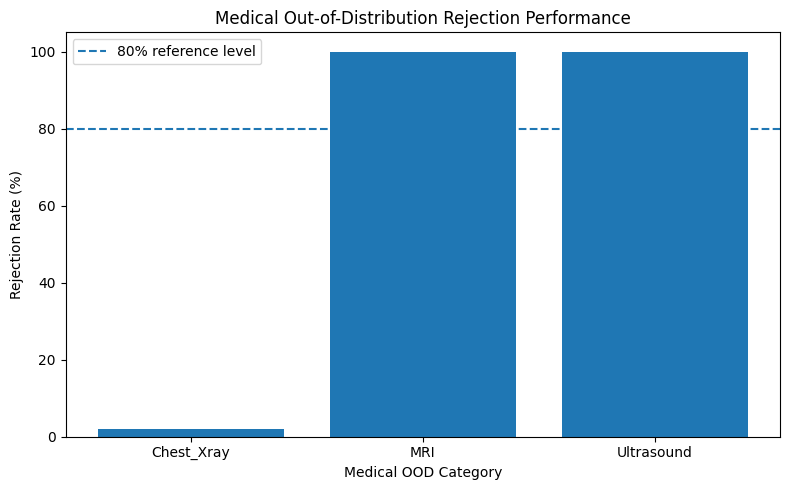

In [58]:
if not medical_ood_summary.empty:

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        medical_ood_summary[
            "Dataset"
        ],

        medical_ood_summary[
            "RejectionRate"
        ]
        * 100
    )

    plt.axhline(
        80,
        linestyle="--",
        label="80% reference level"
    )

    plt.ylabel(
        "Rejection Rate (%)"
    )

    plt.xlabel(
        "Medical OOD Category"
    )

    plt.title(
        "Medical Out-of-Distribution Rejection Performance"
    )

    plt.ylim(
        0,
        105
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

## 22. Domain Validator Experiment Review

The domain validator should only be exported for deployment after
reviewing:

1. overall in-domain validation acceptance;
2. untouched in-domain test acceptance;
3. class-specific Benign and Malignant acceptance;
4. natural-image OOD rejection;
5. CT-vs-CIFAR OOD ROC-AUC;
6. rejection of medically plausible unsupported modalities;
7. qualitative inspection of legitimate CT inputs incorrectly rejected.

No test or external OOD results are used to modify the validation-derived
domain threshold.

In [59]:
print(
    "=" * 70
)

print(
    "DOMAIN VALIDATION REVIEW"
)

print(
    "=" * 70
)


print(
    "Threshold:",
    DOMAIN_THRESHOLD
)

print(
    "Validation CT acceptance:",
    validation_acceptance_rate
)

print(
    "Test CT acceptance:",
    test_acceptance_rate
)

print(
    "Natural-image rejection:",
    cifar_rejection_rate
)

print(
    "CT vs CIFAR ROC-AUC:",
    ct_cifar_ood_auc
)

print(
    "Legitimate test images rejected:",
    len(
        rejected_test_cases
    )
)


print(
    "\nClass-specific acceptance:"
)

display(
    class_acceptance_summary[
        [
            "Class",
            "Samples",
            "Accepted",
            "Rejected",
            "AcceptanceRate"
        ]
    ]
)


print(
    "\nMedical OOD:"
)

display(
    medical_ood_summary
)

DOMAIN VALIDATION REVIEW
Threshold: 0.2859232425689697
Validation CT acceptance: 0.9493670886075949
Test CT acceptance: 0.94921875
Natural-image rejection: 1.0
CT vs CIFAR ROC-AUC: 1.0
Legitimate test images rejected: 13

Class-specific acceptance:


,Class,Samples,Accepted,Rejected,AcceptanceRate
0,Benign,221,217,4,0.981900
1,Malignant,35,26,9,0.742857



Medical OOD:


,Dataset,Samples,MeanDistance,MedianDistance,MinimumDistance,MaximumDistance,Accepted,Rejected,AcceptanceRate,RejectionRate
0,Chest_Xray,51,0.150199,0.129414,0.057763,0.292032,50,1,0.980392,0.019608
1,MRI,80,0.463221,0.458706,0.397988,0.551626,0,80,0.000000,1.000000
2,Ultrasound,55,0.482604,0.485217,0.433678,0.548432,0,55,0.000000,1.000000


##23. Export Domain Reference Embeddings

In [60]:
REFERENCE_PATH = (
    OOD_ROOT
    / "domain_reference_embeddings.npz"
)

np.savez_compressed(
    REFERENCE_PATH,
    embeddings=(
        train_embeddings_norm
        .astype(
            np.float32
        )
    )
)

print(
    "Saved:",
    REFERENCE_PATH
)

Saved: /content/drive/MyDrive/Dissertation/Models/Domain_Validation/domain_reference_embeddings.npz


##24. Export Final Domain Configuration

In [61]:
domain_config = {

    "architecture":
        "DenseNet121",

    "feature_layer":
        FEATURE_LAYER_NAME,

    "method":
        "cosine_knn",

    "k_neighbors":
        K_NEIGHBORS,

    "threshold":
        DOMAIN_THRESHOLD,

    "threshold_percentile":
        THRESHOLD_PERCENTILE,

    "threshold_source":
        "validation_set",

    "input_size":
        list(
            IMAGE_SIZE
        ),

    "reference_samples":
        int(
            train_embeddings_norm.shape[0]
        ),

    "validation_acceptance_rate":
        float(
            validation_acceptance_rate
        ),

    "test_acceptance_rate":
        float(
            test_acceptance_rate
        ),

    "natural_ood_rejection_rate":
        float(
            cifar_rejection_rate
        )
}

In [62]:
#Save: #

CONFIG_PATH = (
    OOD_ROOT
    / "domain_validation_config.json"
)

with open(
    CONFIG_PATH,
    "w"
) as file:

    json.dump(
        domain_config,
        file,
        indent=4
    )

print(
    json.dumps(
        domain_config,
        indent=4
    )
)

{
    "architecture": "DenseNet121",
    "feature_layer": "global_average_pooling",
    "method": "cosine_knn",
    "k_neighbors": 5,
    "threshold": 0.2859232425689697,
    "threshold_percentile": 95,
    "threshold_source": "validation_set",
    "input_size": [
        128,
        128
    ],
    "reference_samples": 1149,
    "validation_acceptance_rate": 0.9493670886075949,
    "test_acceptance_rate": 0.94921875,
    "natural_ood_rejection_rate": 1.0
}


In [63]:
domain_config.update(
    {

        "ct_vs_cifar_roc_auc":
            float(
                ct_cifar_ood_auc
            ),

        "test_benign_acceptance_rate":
            float(
                class_acceptance_summary.loc[
                    class_acceptance_summary[
                        "CancerLabel"
                    ] == 0,
                    "AcceptanceRate"
                ].iloc[0]
            ),

        "test_malignant_acceptance_rate":
            float(
                class_acceptance_summary.loc[
                    class_acceptance_summary[
                        "CancerLabel"
                    ] == 1,
                    "AcceptanceRate"
                ].iloc[0]
            ),

        "legitimate_test_rejections":
            int(
                len(
                    rejected_test_cases
                )
            )
    }
)

In [64]:
for _, row in (
    medical_ood_summary
    .iterrows()
):

    key = (
        row["Dataset"]
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )

    domain_config[
        f"{key}_rejection_rate"
    ] = float(
        row[
            "RejectionRate"
        ]
    )

##25. Export Final Domain Validation Summary

In [65]:
domain_summary = pd.DataFrame(
    [
        {
            "Dataset":
                "Validation CT Nodules",

            "Input Type":
                "In-Domain",

            "Samples":
                len(
                    validation_distances
                ),

            "Acceptance Rate":
                validation_acceptance_rate,

            "Rejection Rate":
                1
                - validation_acceptance_rate
        },

        {
            "Dataset":
                "Test CT Nodules",

            "Input Type":
                "In-Domain",

            "Samples":
                len(
                    test_distances
                ),

            "Acceptance Rate":
                test_acceptance_rate,

            "Rejection Rate":
                1
                - test_acceptance_rate
        },

        {
            "Dataset":
                "CIFAR-10",

            "Input Type":
                "Out-of-Domain",

            "Samples":
                len(
                    cifar_distances
                ),

            "Acceptance Rate":
                1
                - cifar_rejection_rate,

            "Rejection Rate":
                cifar_rejection_rate
        }
    ]
)

display(
    domain_summary
)

,Dataset,Input Type,Samples,Acceptance Rate,Rejection Rate
0,Validation CT Nodules,In-Domain,237,0.949367,0.050633
1,Test CT Nodules,In-Domain,256,0.949219,0.050781
2,CIFAR-10,Out-of-Domain,500,0.000000,1.000000


## Conclusion — Experiment 1: Feature-Space OOD Detection

The DenseNet121 feature-space k-nearest-neighbour domain validator
retained 94.92% of the overall in-domain test set and rejected 100% of
CIFAR-10, MRI and ultrasound inputs.

However, class-specific evaluation identified substantial limitations.

Benign CT acceptance was 98.19%, whereas Malignant CT acceptance was
only 74.29%, indicating that the global feature-distance threshold
disproportionately rejected malignant nodules.

Furthermore, only 1.96% of chest X-ray images were rejected. Therefore,
the feature-space validator did not provide reliable separation between
the supported CT-nodule domain and visually related chest radiographs.

For these reasons, the k-NN domain validator was retained as an
experimental robustness analysis but was not selected for deployment.

A second experiment will evaluate a dedicated supervised input-domain
classifier trained specifically to distinguish supported lung CT nodule
images from unsupported image domains.